Step 1: Install SHAP and Load the Trained Random Forest Model

In [1]:
import shap

print(shap.__version__)

0.52.0


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [3]:
rf_model = joblib.load("../models/random_forest.pkl")

In [5]:
print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [6]:
X_test = pd.read_csv("../data/processed/X_test_scaled.csv")

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [7]:
print(X_test.shape)
print(y_test.shape)

(56746, 30)
(56746,)


In [8]:
print(X_test.head())

       Time        V1        V2        V3        V4        V5        V6  \
0 -0.707761  1.228821 -0.063408  0.274145  0.647465 -0.048135  0.372073   
1  1.273872 -0.203154  1.176678 -0.759595 -0.518472  0.629649 -0.721675   
2 -1.348111 -1.672836  1.401297  1.503940  2.175491  0.699791  1.062139   
3 -0.878056  0.819379 -1.124913  0.515025  0.513945 -1.009048  0.488484   
4  0.727104  2.009701  0.105635 -1.752759  0.588312  0.374801 -0.637884   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.224231  0.079939  0.640759  ... -0.096566 -0.129554 -0.083779 -0.151661   
1  0.638893  0.243377 -0.157488  ... -0.098429  0.384629  1.206754 -0.082753   
2  1.114364 -0.535822 -0.252983  ...  0.828472 -0.525950 -0.408743 -0.280083   
3 -0.580672  0.187686 -0.999142  ... -0.110144 -0.057205 -0.168061 -0.198732   
4  0.009260 -0.129487  0.492619  ... -0.135479  0.008970  0.357394 -0.013472   

        V24       V25       V26       V27       V28    Amount  
0 -0

In [9]:
print(X_test.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')


In [10]:
explainer = shap.TreeExplainer(rf_model)

In [11]:
X_sample = X_test.iloc[:100]

shap_values = explainer.shap_values(X_sample)

In [12]:
shap_values = explainer(X_sample)

In [13]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [14]:
print(shap_values.values.shape)

(100, 30, 2)


In [15]:
joblib.dump(explainer, "../models/shap_explainer.pkl")

joblib.dump(shap_values, "../models/shap_values.pkl")

['../models/shap_values.pkl']

Step 2: Generate Global Feature Importance Using SHAP

In [16]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [17]:
rf_model = joblib.load(
    "../models/random_forest.pkl"
)

In [18]:
X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [19]:
X_sample = X_test.sample(
    500,
    random_state=42
)

In [20]:
explainer = shap.TreeExplainer(
    rf_model
)

In [21]:
shap_values = explainer(X_sample)

In [22]:
shap_values = explainer.shap_values(
    X_sample
)

In [23]:
if hasattr(shap_values, "values"):
    print(shap_values.values.shape)
else:
    print(np.array(shap_values).shape)

(500, 30, 2)


<Figure size 1000x800 with 0 Axes>

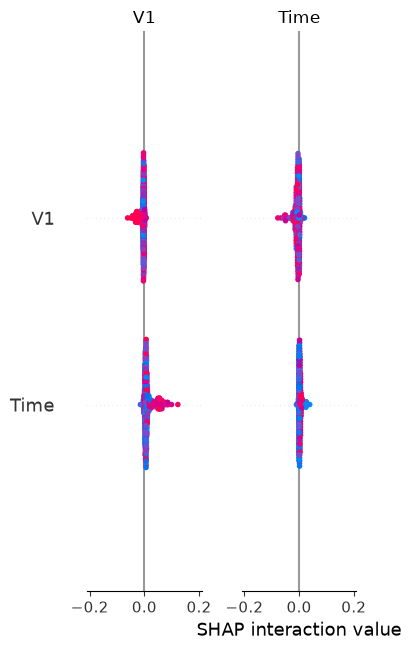

In [24]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../images/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

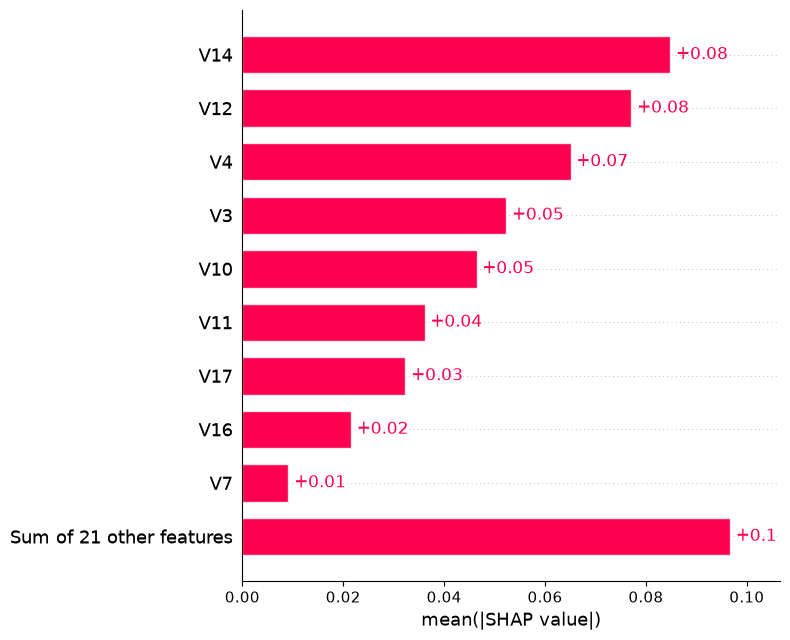

In [14]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

rf_model = joblib.load(
    "../models/random_forest.pkl"
)


explainer = shap.TreeExplainer(rf_model)

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

X_sample = X_test.sample(
    500,
    random_state=42
)

shap_values = explainer(X_sample)

plt.figure(figsize=(10,8))

shap.plots.bar(
    shap_values[:, :, 1],
    max_display=10,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../images/shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
print("X_sample shape:", X_sample.shape)
print("Columns:", len(X_sample.columns))

print("SHAP values shape:", shap_values.values.shape)

importance = np.abs(shap_values.values).mean(axis=0)
print("Importance shape:", importance.shape)

X_sample shape: (500, 30)
Columns: 30
SHAP values shape: (500, 30, 2)
Importance shape: (30, 2)


In [17]:
import shap
import joblib
import pandas as pd
import numpy as np

importance = np.abs(
    shap_values.values[:, :, 1]
).mean(axis=0)

feature_importance = pd.DataFrame({

    "Feature": X_sample.columns,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.084829
12     V12    0.077110
4       V4    0.065059
3       V3    0.052293
10     V10    0.046422
11     V11    0.036128
17     V17    0.032313
16     V16    0.021529
7       V7    0.009120
8       V8    0.009024


In [18]:
feature_importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

In [19]:
print(
    feature_importance.head(10)
)

   Feature  Importance
14     V14    0.084829
12     V12    0.077110
4       V4    0.065059
3       V3    0.052293
10     V10    0.046422
11     V11    0.036128
17     V17    0.032313
16     V16    0.021529
7       V7    0.009120
8       V8    0.009024


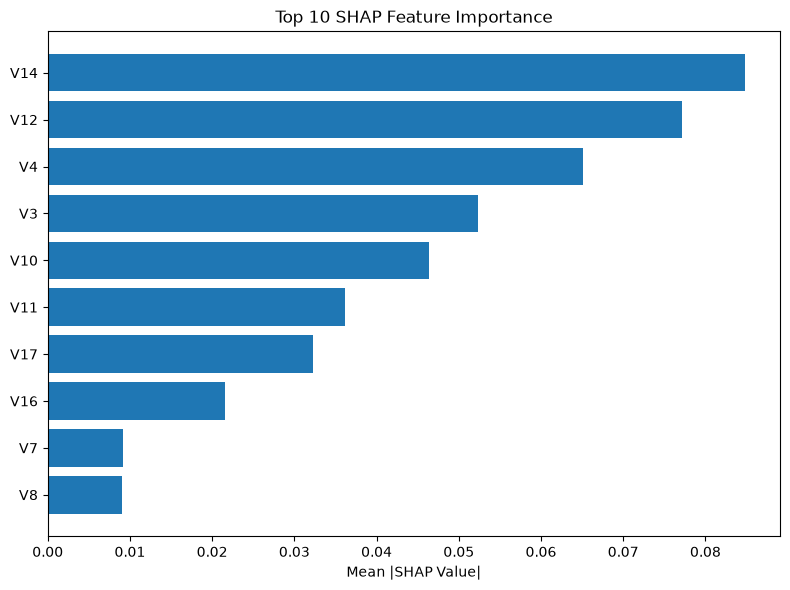

In [20]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 SHAP Feature Importance")

plt.xlabel("Mean |SHAP Value|")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../images/top10_shap_features.png",
    dpi=300
)

plt.show()